In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from joblib import Parallel, delayed

import camb
import healpy as hp

from sbi.utils import BoxUniform
from sbi.inference import NPE
from sbi.analysis import pairplot, plot_summary

# -----------------------------
# 0) Global Config
# -----------------------------
_ = torch.manual_seed(42)
_ = np.random.seed(0)


# -----------------------------
# 1) & 2) The Object-Oriented Simulator & Compressor
# -----------------------------
class CMBSimulator:
    def __init__(self, lmax=3000, beam_fwhm=5.0, noise_profile_name="split1"):
        """
        Initializes the CAMB simulator, calculates the fiducial model, 
        and pre-computes the MOPED derivatives for a SPECIFIC noise profile.
        """
        self.lmax = lmax
        self.beam_fwhm = beam_fwhm
        self.noise_profile_name = noise_profile_name
        
        # Fiducial CAMB params
        self.param_dict = {
            "H0": 67.5, "ombh2": 0.022, "omch2": 0.122,
            "mnu": 0.06, "omk": 0.0, "tau": 0.06,
            "As": 2e-9, "ns": 0.965,
            "halofit_version": "mead", "lmax": self.lmax
        }
        
        # Step sizes for numerical derivatives
        self.derivatives = {"H0": 0.001, "ombh2": 0.005, "omch2": 0.005, "As": 0.005, "ns": 0.005}
        
        # Pre-compute the beam
        self.beam = hp.gauss_beam(self.beam_fwhm / 60 / 180 * np.pi, lmax=self.lmax)
        
        # Load the specific noise profile
        nl_base = np.ones(self.lmax + 1) * (20/60/180*60)**2
        self.nl_dict = {
            "split1": nl_base,
            "split2": 1.3 * nl_base,
            "none":   np.zeros(self.lmax + 1),
        }
        self.noise_cl = self.nl_dict[self.noise_profile_name]
        
        # Build MOPED components during initialization
        self.fiducial_cl, self.cov_diag, self.derivs_matrix = self._build_compression()

    def _theta_to_camb_params(self, theta_vec):
        """Converts SBI proposed theta [H0, ombh2, omch2, As10, ns] back to CAMB params."""
        H0, ombh2, omch2, As10, ns = theta_vec
        p = dict(self.param_dict)
        p["H0"] = float(H0)
        p["ombh2"] = float(ombh2)
        p["omch2"] = float(omch2)
        p["As"] = float(As10) * 1e-10
        p["ns"] = float(ns)
        return p

    def _get_spectrum(self, params):
        """Runs CAMB and applies the beam and mean noise level."""
        pars = camb.set_params(**params)
        results = camb.get_results(pars)
        cl_tt = results.get_cmb_power_spectra(pars, CMB_unit="muK", raw_cl=True)["total"][:self.lmax+1, 0]

        # Add beam^2 and mean noise to the theory spectrum
        mu = cl_tt * (self.beam**2) + self.noise_cl
        return mu[2:]  # drop ell=0,1

    def _build_compression(self):
        """Calculates fiducial spectrum, cosmic variance, and numerical derivatives."""
        fiducial = self._get_spectrum(self.param_dict)
        
        # Diagonal Gaussian variance approx
        ell_use = np.arange(2, self.lmax + 1)
        cov_diag = 2.0 / (2 * ell_use + 1) * (fiducial**2)
        
        # Calculate numerical derivatives
        derivs = []
        for name, frac in self.derivatives.items():
            step = self.param_dict[name] * frac

            p_up = dict(self.param_dict); p_up[name] += step
            p_dn = dict(self.param_dict); p_dn[name] -= step

            up = self._get_spectrum(p_up)
            dn = self._get_spectrum(p_dn)

            denom = 2 * step
            if name == "As": denom *= 1e10 # Scaling trick

            derivs.append((up - dn) / denom)

        return fiducial, cov_diag, np.asarray(derivs)

    def compress(self, cl_hat):
        """Applies MOPED compression to a single noisy observation."""
        d = cl_hat[:self.lmax+1][2:] # Drop ell=0,1
        return self.derivs_matrix @ ((d - self.fiducial_cl) / self.cov_diag)

    def simulate_and_compress(self, theta_vec):
        """
        The main worker function for training data generation.
        Generates one random sky, applies noise, and compresses.
        """
        p = self._theta_to_camb_params(theta_vec)
        pars = camb.set_params(**p)
        results = camb.get_results(pars)
        cl_tt = results.get_cmb_power_spectra(pars, CMB_unit="muK", raw_cl=True)["total"][:self.lmax+1, 0]

        # 1. Realize the sky
        cmb_alm = hp.synalm(cl_tt, lmax=self.lmax)
        
        # 2. Apply Beam
        alm_obs = hp.almxfl(cmb_alm, self.beam)
        
        # 3. Add Noise specific to this simulator instance
        noise_alm = hp.synalm(self.noise_cl, lmax=self.lmax)
        alm_obs = alm_obs + noise_alm
        
        # 4. Extract Cl and Compress
        cl_hat = hp.alm2cl(alm_obs)
        return self.compress(cl_hat)


# -----------------------------
# 3) Priors 
# -----------------------------
def define_uniform_prior():
    low  = torch.tensor([60.0, 0.020, 0.105, 10.0, 0.92])
    high = torch.tensor([75.0, 0.024, 0.140, 35.0, 1.02])
    return BoxUniform(low=low, high=high)


# -----------------------------
# 4) Training Data Generation (Parallel-Safe)
# -----------------------------
def generate_training_data(prior, num_samples, noise_profile="split1", n_jobs=4):
    """Generates training data safely using the CMBSimulator class."""
    theta_samples = prior.sample((num_samples,))
    
    # Initialize exactly ONE simulator for the workers to share
    sim = CMBSimulator(noise_profile_name=noise_profile)
    
    # Generate data in parallel
    x_list = Parallel(n_jobs=n_jobs)(
        delayed(sim.simulate_and_compress)(theta.numpy()) for theta in theta_samples
    )
    
    x_samples = torch.as_tensor(np.asarray(x_list), dtype=torch.float32)
    return theta_samples, x_samples


# -----------------------------
# 4.5) The "Same Sky" Null Test Generator
# -----------------------------
def generate_null_test_splits(theta_true, noise_profile_1="split1", noise_profile_2="split2"):
    """
    CRITICAL FIX: Generates ONE true underlying CMB sky, and observes it 
    through TWO different noise/systematic profiles.
    """
    # Initialize simulators to get the correct noise levels and compressors
    sim1 = CMBSimulator(noise_profile_name=noise_profile_1)
    sim2 = CMBSimulator(noise_profile_name=noise_profile_2)
    
    # Get true theory spectrum
    p = sim1._theta_to_camb_params(theta_true)
    pars = camb.set_params(**p)
    results = camb.get_results(pars)
    cl_theory = results.get_cmb_power_spectra(pars, CMB_unit="muK", raw_cl=True)["total"][:sim1.lmax+1, 0]
    
    # Generate the ONE true sky (a_lm)
    alm_true = hp.synalm(cl_theory, lmax=sim1.lmax)
    
    # Apply Beam to true sky
    alm_blurred = hp.almxfl(alm_true, sim1.beam)
    
    # Observation 1 (Split 1 Systematics)
    noise_alm_1 = hp.synalm(sim1.noise_cl, lmax=sim1.lmax)
    cl_obs_1 = hp.alm2cl(alm_blurred + noise_alm_1)
    x1 = sim1.compress(cl_obs_1)
    
    # Observation 2 (Split 2 Systematics)
    noise_alm_2 = hp.synalm(sim2.noise_cl, lmax=sim2.lmax)
    cl_obs_2 = hp.alm2cl(alm_blurred + noise_alm_2)
    x2 = sim2.compress(cl_obs_2)
    
    return torch.as_tensor(x1, dtype=torch.float32), torch.as_tensor(x2, dtype=torch.float32)


# -----------------------------
# 5) Training Loop
# -----------------------------
def train_net_generate_samples(x, theta, x_obs, prior, verbose, max_epoch, true_val):
    inference = NPE(prior=prior, density_estimator="nsf")
    posterior_net = inference.append_simulations(theta, x).train(max_num_epochs=max_epoch, stop_after_epochs=30)
    
    posterior_direct = inference.build_posterior(density_estimator=posterior_net, sample_with="direct")
    
    # Generate samples from the posterior conditioned on the observation
    samples = posterior_direct.sample((1000,), x=x_obs)

    if verbose:
        _ = plot_summary(inference, tags=["training_loss", "validation_loss"], figsize=(10, 2))
        plt.show()
        
        print("Observation x_obs:", x_obs)

        _ = pairplot(
            samples,
            points=true_val[None, :],
            figsize=(6, 6)
        )
        plt.show()
        
    return posterior_direct

/home/vasir/cmb-work/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


1. Defining Prior
2. Setting up Mock Observation
3. Generating CAMB Training Data
4. Training Neural Posterior Estimator
 Neural network successfully converged after 166 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/home/vasir/cmb-work/sbi-logs/NPE_C/2026-03-12T14_47_03.618341' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


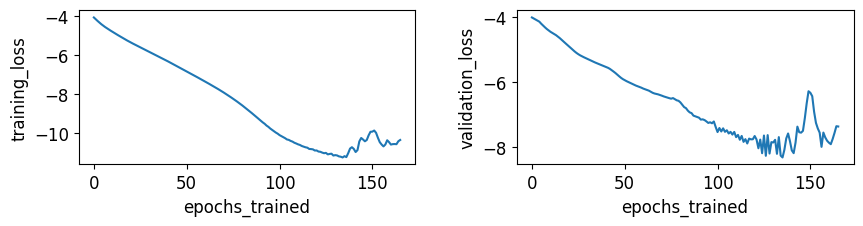

Observation x_obs: tensor([-1.2599e+02,  6.8835e+04, -1.5268e+05,  1.9664e+03, -3.7952e+03])


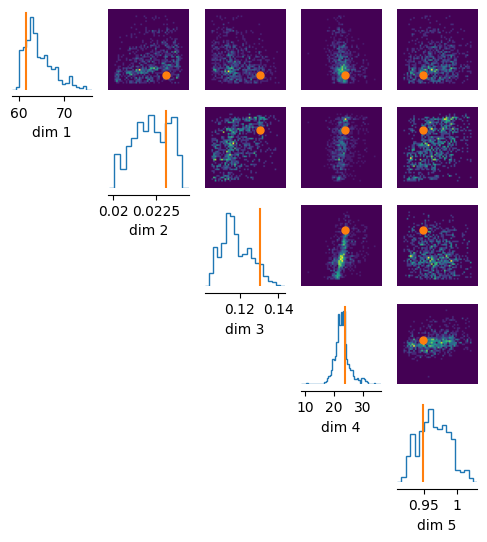

In [3]:
# 1. Initialize the Prior
print("1. Defining Prior")
prior = define_uniform_prior()

# 2. Pick a "True" Universe for the mock observation
print("2. Setting up Mock Observation")
true_theta = prior.sample((1,)).squeeze(0)

# Use our new function to get a rigorous observation (we'll just use split 1 for the demo)
x_obs_1, _ = generate_null_test_splits(true_theta, "split1", "split2")

# 3. Generate Training Data 
print("3. Generating CAMB Training Data")
num_sims = 200 
theta_train, x_train = generate_training_data(prior, num_samples=num_sims, noise_profile="split1", n_jobs=4)

# 4. Train the Neural Network and Plot Results
print("4. Training Neural Posterior Estimator")

posterior = train_net_generate_samples(
    x=x_train, 
    theta=theta_train, 
    x_obs=x_obs_1, 
    prior=prior, 
    verbose=True, 
    max_epoch=1000, 
    true_val=true_theta
)